In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start="2000-01-01", end="2020-12-31", freq='M')

temperature = 25 + 0.02 * np.arange(len(dates)) + np.random.normal(0, 1.5, len(dates))
rainfall = 100 + 50 * np.sin(np.linspace(0, 20, len(dates))) + np.random.normal(0, 10, len(dates))
humidity = 60 + 10 * np.sin(np.linspace(0, 10, len(dates))) + np.random.normal(0, 5, len(dates))
co2 = 350 + 0.5 * np.arange(len(dates)) + np.random.normal(0, 2, len(dates))

df = pd.DataFrame({
    "Date": dates,
    "Temperature": temperature,
    "Rainfall": rainfall,
    "Humidity": humidity,
    "CO2": co2
})

df.to_csv("climate_data.csv", index=False)

print("✅ Dataset created")
df.head()

✅ Dataset created


/tmp/ipykernel_11845/127295719.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2000-01-01", end="2020-12-31", freq='M')


,Date,Temperature,Rainfall,Humidity,CO2
0,2000-01-31,25.745071,121.221562,56.746787,350.986636
1,2000-02-29,24.812604,114.304502,57.962674,350.869672
2,2000-03-31,26.011533,92.740744,57.834000,349.283284
3,2000-04-30,27.344545,106.996347,56.872422,352.900620
4,2000-05-31,24.728770,128.336918,61.829497,350.848724


In [2]:
df = pd.read_csv("climate_data.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

df.isnull().sum()

,0
Date,0
Temperature,0
Rainfall,0
Humidity,0
CO2,0


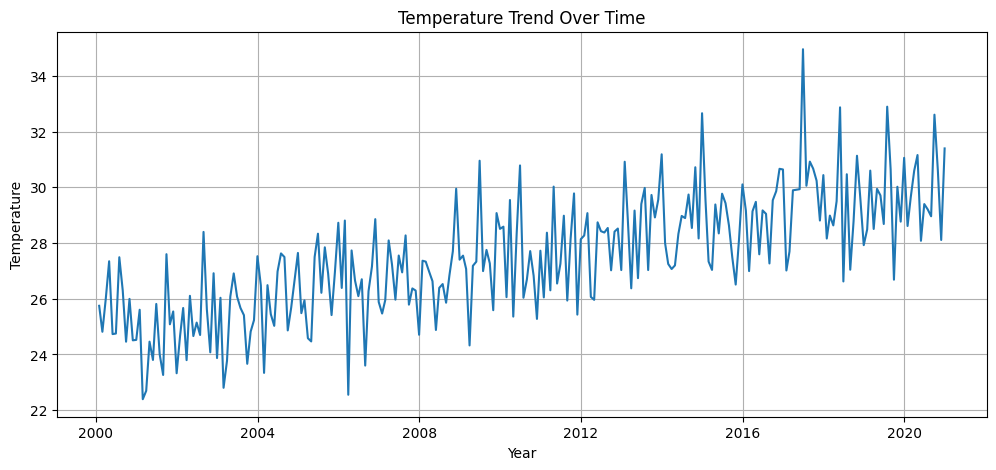

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Temperature'])
plt.title("Temperature Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.grid()
plt.show()

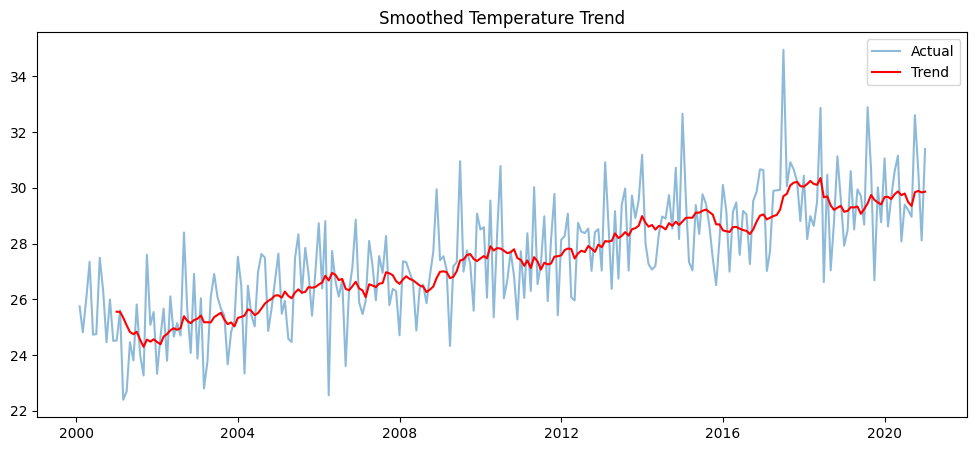

In [4]:
df['Rolling_Avg'] = df['Temperature'].rolling(window=12).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Temperature'], alpha=0.5, label='Actual')
plt.plot(df['Date'], df['Rolling_Avg'], color='red', label='Trend')
plt.legend()
plt.title("Smoothed Temperature Trend")
plt.show()

In [5]:
mean = df['Temperature'].mean()
std = df['Temperature'].std()

anomalies = df[(df['Temperature'] > mean + 2*std) |
               (df['Temperature'] < mean - 2*std)]

print("Anomalies Found:")
anomalies.head()

Anomalies Found:


,Date,Temperature,Rainfall,Humidity,CO2,Rolling_Avg
13,2001-02-28,22.390080,130.537135,60.063036,360.124897,25.340212
14,2001-03-31,22.692623,161.231483,65.789607,358.415504,25.063636
37,2003-02-28,22.800495,103.382123,64.304755,365.946503,25.175329
74,2006-03-31,22.550382,92.721115,54.528892,384.311099,26.673638
179,2014-12-31,32.660254,129.212676,69.948372,438.495892,28.793190


In [6]:
from sklearn.linear_model import LinearRegression
import numpy as np

df['Year'] = df['Date'].dt.year

X = df[['Year']]
y = df['Temperature']

model = LinearRegression()
model.fit(X, y)

future_year = np.array([[2030]])
prediction = model.predict(future_year)

print("🌡 Predicted Temperature in 2030:", prediction[0])

🌡 Predicted Temperature in 2030: 32.68936533950074


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:
from google.colab import files
files.download("climate_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>